In [3]:
!git clone https://github.com/rasbt/reasoning-from-scratch.git
%cd reasoning-from-scratch
!pip install -r requirements.txt

Cloning into 'reasoning-from-scratch'...
remote: Enumerating objects: 2071, done.
remote: Counting objects: 100% (779/779), done.
remote: Compressing objects: 100% (304/304), done.
remote: Total 2071 (delta 626), reused 488 (delta 475), pack-reused 1292 (from 3)
Receiving objects: 100% (2071/2071), 4.85 MiB | 16.13 MiB/s, done.
Resolving deltas: 100% (1312/1312), done.
/content/reasoning-from-scratch/reasoning-from-scratch


# Generating Text from Pretrained LLM -> Qwen3 Inference Script

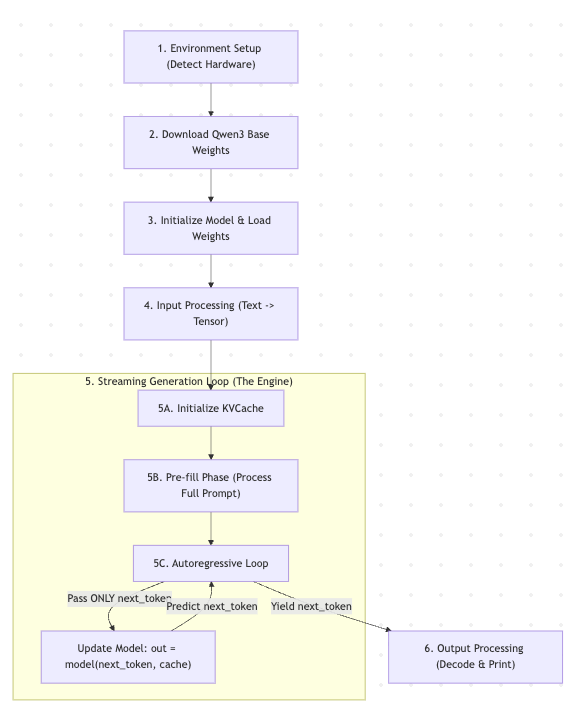

## What this script does
Loads a pre-trained **Qwen3 0.6B base model**, encodes a text prompt, and streams
generated tokens back to the terminal one at a time using greedy decoding + a KV-Cache.

---

## 1. `get_device()`
Picks the best available hardware in priority order:
**CUDA → MPS → XPU → CPU**

If CUDA is found, **TF32 precision** is enabled on matrix multiplications — a free
speed boost on Ampere+ GPUs. The API to enable it changed in PyTorch 2.9, so the
function branches on the version number to handle both.

---

## 2. `generate_text_basic_stream_cache()`
A generator function (uses `yield`) that produces one token per iteration.

| Phase | What happens |
|---|---|
| **Prefill** | The full prompt is passed through the model once. Only the last position's logits (`[:, -1]`) are kept — these predict the next token. |
| **Decode loop** | `argmax` greedily picks the highest-logit token. That single token is fed back into the model. The **KV-Cache** supplies all prior context so the model only processes the new token each step, not the whole sequence. |

Generation stops at `max_new_tokens` or when the **EOS token** is produced.

`@torch.inference_mode()` disables gradient tracking throughout for speed and lower memory use.

---

## 3. Setup & Execution

```
download weights → load tokenizer → build model → load state dict → (optional) torch.compile
```

- **`weights_only=True`** in `torch.load` — safer checkpoint loading, skips arbitrary Python objects.
- **`torch.compile`** — traces the model and emits optimised native kernels. Wrapped in `try/except` because it can fail on some platforms (Windows, older CUDA).
- **Tokenizer flags all `False`** — plain text completion mode; no chat template, no assistant turn marker, no `<think>` token.
- **`unsqueeze(0)`** — adds the batch dimension to the token ID tensor: `(seq_len,) → (1, seq_len)`.
- **`flush=True`** in `print` — forces each decoded token to appear in the terminal immediately rather than waiting for a newline.

In [4]:
import torch
import time

# Import the custom Qwen3 package components.
# Using the full package path (reasoning_from_scratch.qwen3) is required
# so that relative imports inside the package resolve correctly.
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,   # Downloads model weights and tokenizer files
    Qwen3Model,             # The Qwen3 transformer model class
    Qwen3Tokenizer,         # Tokenizer for encoding/decoding text
    QWEN_CONFIG_06_B,       # Pre-defined config dict for the 0.6B parameter model
    KVCache                 # Key-Value cache to speed up autoregressive generation
)


# ─────────────────────────────────────────────
# 1. HARDWARE DETECTION
# ─────────────────────────────────────────────
def get_device(enable_tensor_cores=True):
    """
    Detects and returns the best available compute device in priority order:
      CUDA (NVIDIA GPU) → MPS (Apple Silicon) → XPU (Intel GPU) → CPU

    If a CUDA GPU is found and enable_tensor_cores=True, TF32 precision is
    enabled for matrix multiplications and convolutions. TF32 gives a free
    speed boost on Ampere+ GPUs with negligible accuracy loss.

    The API for enabling TF32 changed in PyTorch 2.9, so we branch on the
    version number to stay compatible with both old and new installs.
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")

        if enable_tensor_cores:
            # Parse the major and minor version numbers (e.g. "2.9.1" → 2, 9)
            major, minor = map(int, torch.__version__.split(".")[:2])

            if (major, minor) >= (2, 9):
                # New API introduced in PyTorch 2.9
                torch.backends.cuda.matmul.fp32_precision = "tf32"
                torch.backends.cudnn.conv.fp32_precision  = "tf32"
            else:
                # Legacy API for PyTorch < 2.9
                torch.backends.cuda.matmul.allow_tf32 = True
                torch.backends.cudnn.allow_tf32        = True

    elif torch.backends.mps.is_available():
        # Apple Silicon (M1/M2/M3) GPU via Metal Performance Shaders
        device = torch.device("mps")

    elif torch.xpu.is_available():
        # Intel discrete GPU (Arc / Ponte Vecchio)
        device = torch.device("xpu")

    else:
        # Fallback: run everything on the CPU
        device = torch.device("cpu")

    return device


# ─────────────────────────────────────────────
# 2. STREAMING TEXT GENERATION WITH KV-CACHE
# ─────────────────────────────────────────────
@torch.inference_mode()  # Disables gradient tracking for faster, lower-memory inference
def generate_text_basic_stream_cache(model, token_ids, max_new_tokens, eos_token_id=None):
    """
    Generates text one token at a time using greedy decoding, yielding each
    token as soon as it is produced (streaming).

    Uses a KV-Cache so that previously computed attention keys/values are
    reused instead of recomputed on every step — this makes each step O(n)
    rather than O(n²) in sequence length.

    Args:
        model          : The loaded Qwen3 language model.
        token_ids      : (1, seq_len) integer tensor of prompt token IDs.
        max_new_tokens : Hard cap on how many tokens to generate.
        eos_token_id   : If provided, generation stops early when this token
                         is produced (end-of-sequence signal).

    Yields:
        next_token : (1, 1) integer tensor containing the newly sampled token.
    """
    model.eval()

    # Allocate an empty KV-Cache sized for this model's number of layers.
    # The cache grows automatically as tokens are generated.
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()  # Clear any stale cache state from a previous run

    # ── Prefill phase ──────────────────────────────────────────────────────
    # Feed the entire prompt through the model in one forward pass.
    # [:, -1] selects only the logits for the very last token position,
    # which represents the model's prediction for what comes next.
    out = model(token_ids, cache=cache)[:, -1]

    # ── Autoregressive decode loop ─────────────────────────────────────────
    for _ in range(max_new_tokens):

        # Greedy decoding: pick the token with the highest logit score.
        # keepdim=True preserves the (batch, 1) shape expected by the model.
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        # Stop early if every sequence in the batch has hit the EOS token.
        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token  # Stream this token back to the caller immediately

        # Feed only the single new token back into the model.
        # The KV-Cache supplies all previous context, so this is very fast.
        out = model(next_token, cache=cache)[:, -1]


# ─────────────────────────────────────────────
# 3. SETUP AND EXECUTION
# ─────────────────────────────────────────────

# --- Device ---
device = get_device()
print(f"Using device: {device}")

# --- Download weights (skipped automatically if files already exist) ---
download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")

# --- Tokenizer ---
# Configured for plain text completion (no chat template, no special tokens).
tokenizer = Qwen3Tokenizer(
    tokenizer_file_path="qwen3/tokenizer-base.json",
    apply_chat_template=False,   # Don't wrap the prompt in <|im_start|> / <|im_end|> tags
    add_generation_prompt=False, # Don't append the assistant turn marker
    add_thinking=False           # Don't prepend the <think> reasoning token
)

# --- Model ---
# Instantiate the model architecture from the 0.6B config, then load
# pre-trained weights from disk into it.
model = Qwen3Model(QWEN_CONFIG_06_B)

state = torch.load(
    "qwen3/qwen3-0.6B-base.pth",
    map_location=device,  # Load weights directly onto the target device
    weights_only=True     # Safer load: skips arbitrary Python objects in the checkpoint
)
model.load_state_dict(state)
model.to(device)
model.eval()  # Switch to inference mode (disables dropout, etc.)

# --- Optional compilation ---
# torch.compile traces the model and emits optimised native kernels,
# giving a significant throughput boost on repeated calls.
# It can fail on some platforms (e.g. Windows, older CUDA), so we catch
# errors and fall back to the uncompiled model gracefully.
try:
    model = torch.compile(model)
    print("Model compiled successfully.")
except Exception as e:
    print(f"Skipping torch.compile due to error: {e}")

# --- Prompt encoding ---
prompt = "Explain large language models in a single sentence."
input_ids = tokenizer.encode(prompt)

# unsqueeze(0) adds a batch dimension: shape becomes (1, seq_len)
input_token_ids_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)

# --- Run generation and stream output ---
print("\n" + "=" * 50)
print(f"Prompt: {prompt}\n")
print("Response: ", end="")

start_time = time.time()

for token in generate_text_basic_stream_cache(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=50,
    eos_token_id=tokenizer.eos_token_id
):
    # Unwrap the (1, 1) tensor to a plain Python int, then decode to a string.
    # flush=True forces the character to appear immediately (no output buffering).
    token_id = token.squeeze(0).item()
    print(tokenizer.decode([token_id]), end="", flush=True)

print(f"\n\nTotal Generation Time: {time.time() - start_time:.2f} seconds")
print("=" * 50)

Using device: cuda
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)
Model compiled successfully.

Prompt: Explain large language models in a single sentence.

Response: 

W0325 02:52:50.524000 8540 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


 Large

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


 language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Total Generation Time: 39.43 seconds
